# Notebook 01 — Análisis exploratorio de datos (EDA)

**TFM · Máster en Inteligencia Artificial · Manuel Montilla Luna**

**Mantenimiento predictivo de motores de turbofán — Dataset NASA C-MAPSS**

El objetivo de este notebook es entender la estructura del dataset y extraer los hallazgos que justifican las decisiones de
preprocesado del notebook

## 1. Configuración del entorno

La estructura de carpetas es la siguiente:

```
tfm/
├── data/CMAPSSData/     ← los 12 ficheros .txt de NASA
├── notebooks/
└── reports/figures/     ← imágenes generadas
```

In [ ]:
import sys
from pathlib import Path

from google.colab import drive
drive.mount("/content/drive")

# Ajusta esta ruta si subes el proyecto a otra carpeta de tu Drive
PROJECT_DIR = Path("/content/drive/MyDrive/ColabNotebooks/tfm")
DATA_DIR    = PROJECT_DIR / "data" / "CMAPSSData"
FIG_DIR     = PROJECT_DIR / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Proyecto : {PROJECT_DIR}")
print(f"Datos    : {DATA_DIR}   (existe: {DATA_DIR.exists()})")

Mounted at /content/drive
Proyecto : /content/drive/MyDrive/ColabNotebooks/tfm
Datos    : /content/drive/MyDrive/ColabNotebooks/tfm/data/CMAPSSData   (existe: True)


Importamos las librerías necesarias y configuramos la visualización de datos para todo el notebook

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid", palette="deep")    # Configuramos el aspecto de las gráficas que crearemos con Seaborn
plt.rcParams["figure.dpi"] = 110                    # Resolución con la que se muestran las figuras
plt.rcParams["savefig.dpi"] = 150                   # Resolución con la que se guardan las figuras
pd.set_option("display.width", 140)                 # Cuántos caracteres de ancho usa pandas antes de cortar la línea al imprimir un dataframe
pd.set_option("display.max_columns", 40)            # Máximo de columnas que pandas muestra antes de resumir con "..."

RANDOM_STATE = 23
np.random.seed(RANDOM_STATE)

## 2. Esquema de datos y funciones de carga

Los ficheros de C-MAPSS son texto plano sin cabecera, con 26 columnas separadas por espacios.
Cada fila es un ciclo de operación (un vuelo completo) de una unidad de motor concreta.

| Subset | Motores train | Condiciones operativas | Modos de fallo |
|---|---|---|---|
| FD001 | 100 | 1 | 1 |
| FD002 | 260 | 6 | 1 |
| FD003 | 100 | 1 | 2 |
| FD004 | 249 | 6 | 2 |

Se ha buscado en la documentación de los datasets a qué hace referencia cada columna, ya que en ellos no hay cabeceras. Las 26 columnas son, en orden:
unit, cycle, setting_1..3, sensor_1..21

Se van a agrupar la información que se tiene de la estructura de los datasets para proceder a ejecutar la EDA.

In [ ]:
INDEX_COLS   = ["unit", "cycle"]
SETTING_COLS = ["setting_1", "setting_2", "setting_3"]
SENSOR_COLS  = [f"sensor_{i}" for i in range(1, 22)]
ALL_COLS     = INDEX_COLS + SETTING_COLS + SENSOR_COLS

SUBSETS = ("FD001", "FD002", "FD003", "FD004")

# Numero de condiciones operativas de cada subset. Determina si hay que
# aplicar normalizacion por regimen.
N_CONDITIONS = {"FD001": 1, "FD002": 6, "FD003": 1, "FD004": 6}

# Numero de modos de fallo. Solo con fines descriptivos.
N_FAULT_MODES = {"FD001": 1, "FD002": 1, "FD003": 2, "FD004": 2}

A continuación se define una clase con la que se crerá una instancia por cada dataset que se procese.

In [ ]:
@dataclass
class CMAPSSSubset: # Contenedor de un subset completo de C-MAPSS

    name: str                    # Nombre del dataset
    train: pd.DataFrame          # Conjunto de train del dataset
    test: pd.DataFrame           # Cnjunto de test del dataset
    rul_test: pd.Series          # RUL real de cada motor de test, indexado por unit

    @property                    # Atributo calculado con el atributo self.name
    def n_conditions(self):
        return N_CONDITIONS[self.name]

    @property                    # Atributo calculado con el atributo self.name
    def n_fault_modes(self):
        return N_FAULT_MODES[self.name]

    def summary(self):
        """Resumen descriptivo, reutilizable en la tabla de la memoria."""
        return pd.Series({       # Se utiliza pd.Series porque más adelante se va a crear una comparativa entre datasets
            "subset": self.name,
            "condiciones_operativas": self.n_conditions,
            "modos_de_fallo": self.n_fault_modes,
            "motores_train": self.train["unit"].nunique(),
            "motores_test": self.test["unit"].nunique(),
            "filas_train": len(self.train),
            "filas_test": len(self.test),
            "ciclos_min_train": int(self.train.groupby("unit")["cycle"].max().min()),
            "ciclos_max_train": int(self.train.groupby("unit")["cycle"].max().max()),
            "ciclos_medios_train": round(
                float(self.train.groupby("unit")["cycle"].max().mean()), 1),
        })

Se van a definir las funciones necesarias para la importación de los datasets

In [ ]:
def _read_cmapss_file(path): #  Lee un fichero train_FD00X.txt o test_FD00X.txt

    """
    Los ficheros originales terminan cada linea con dos espacios. Con `sep=" "` pandas generaria dos columnas fantasma llenas de
    NaN. Usando la expresion `\s+` como separador el problema desaparece.
    """

    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"No se encuentra {path}. Descarga C-MAPSS y coloca los .txt ahi.")

    df = pd.read_csv(path, sep=r"\s+", header=None, engine="python")

    if df.shape[1] != len(ALL_COLS):
        raise ValueError(
            f"{path.name}: se esperaban {len(ALL_COLS)} columnas y se han leido "
            f"{df.shape[1]}. Revisa que el fichero no este corrupto.")

    df.columns = ALL_COLS
    return df.astype({"unit": "int32", "cycle": "int32"})


def _read_rul_file(path): # Lee RUL_FD00X.txt. Una linea por motor de test con su RUL real

    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No se encuentra {path}.")

    rul = pd.read_csv(path, sep=r"\s+", header=None, engine="python").iloc[:, 0]
    rul.name = "RUL"
    rul.index = range(1, len(rul) + 1)      # indexado por numero de unit (1-based)
    return rul.astype("int32")


def load_subset(name, data_dir=None): # Carga un subset completo: train + test + RUL de test

    name = name.upper()
    if name not in SUBSETS:
        raise ValueError(f"Subset desconocido: {name}. Opciones: {SUBSETS}")

    data_dir = Path(data_dir if data_dir is not None else DATA_DIR)
    return CMAPSSSubset(
        name=name,
        train=_read_cmapss_file(data_dir / f"train_{name}.txt"),
        test=_read_cmapss_file(data_dir / f"test_{name}.txt"),
        rul_test=_read_rul_file(data_dir / f"RUL_{name}.txt"),
    )


def load_all(data_dir=None): # Carga los cuatro subsets en un diccionario indexado por nombre

    return {name: load_subset(name, data_dir) for name in SUBSETS}


def describe_all(subsets): # Tabla descriptiva de los cuatro subsets

    return pd.DataFrame([s.summary() for s in subsets.values()]).set_index("subset")

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1281/2127997248.py:5: SyntaxWarning: invalid escape sequence '\s'
  NaN. Usando la expresion `\s+` como separador el problema desaparece.


## 3. Carga de los cuatro subsets

C-MAPSS no es un dataset sino cuatro, y el conjunto constituye un diseño experimental
factorial 2×2: dos niveles de condiciones operativas (1 o 6) cruzados con dos niveles de
modos de fallo (1 o 2). Esa estructura es la que permitirá atribuir la pérdida de rendimiento
de los modelos a una causa concreta.

In [ ]:
subsets = load_all(DATA_DIR)
print("Subsets cargados:", list(subsets.keys()))

subsets["FD001"].train.head()

Subsets cargados: ['FD001', 'FD002', 'FD003', 'FD004']


,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 4. Descripción de las fuentes de datos

In [ ]:
tabla_descriptiva = describe_all(subsets)
tabla_descriptiva.T

subset,FD001,FD002,FD003,FD004
condiciones_operativas,1.0,6.0,1.0,6.0
modos_de_fallo,1.0,1.0,2.0,2.0
motores_train,100.0,260.0,100.0,249.0
motores_test,100.0,259.0,100.0,248.0
filas_train,20631.0,53759.0,24720.0,61249.0
filas_test,13096.0,33991.0,16596.0,41214.0
ciclos_min_train,128.0,128.0,145.0,128.0
ciclos_max_train,362.0,378.0,525.0,543.0
ciclos_medios_train,206.3,206.8,247.2,246.0


In [ ]:
total_filas   = sum(len(s.train) + len(s.test) for s in subsets.values())
total_motores = sum(s.train["unit"].nunique() + s.test["unit"].nunique() for s in subsets.values())

print(f"Filas totales (train + test) : {total_filas:,}")
print(f"Trayectorias de motor totales: {total_motores:,}")
print(f"Filas solo de train          : {sum(len(s.train) for s in subsets.values()):,}")

Filas totales (train + test) : 265,256
Trayectorias de motor totales: 1,416
Filas solo de train          : 160,359


## 5. Distribución de la vida útil de los motores

Cada motor de entrenamiento se opera hasta el fallo, de modo que su último ciclo registrado
equivale a su vida útil total. La dispersión de esa magnitud indica cuánta heterogeneidad debe
absorber el modelo.

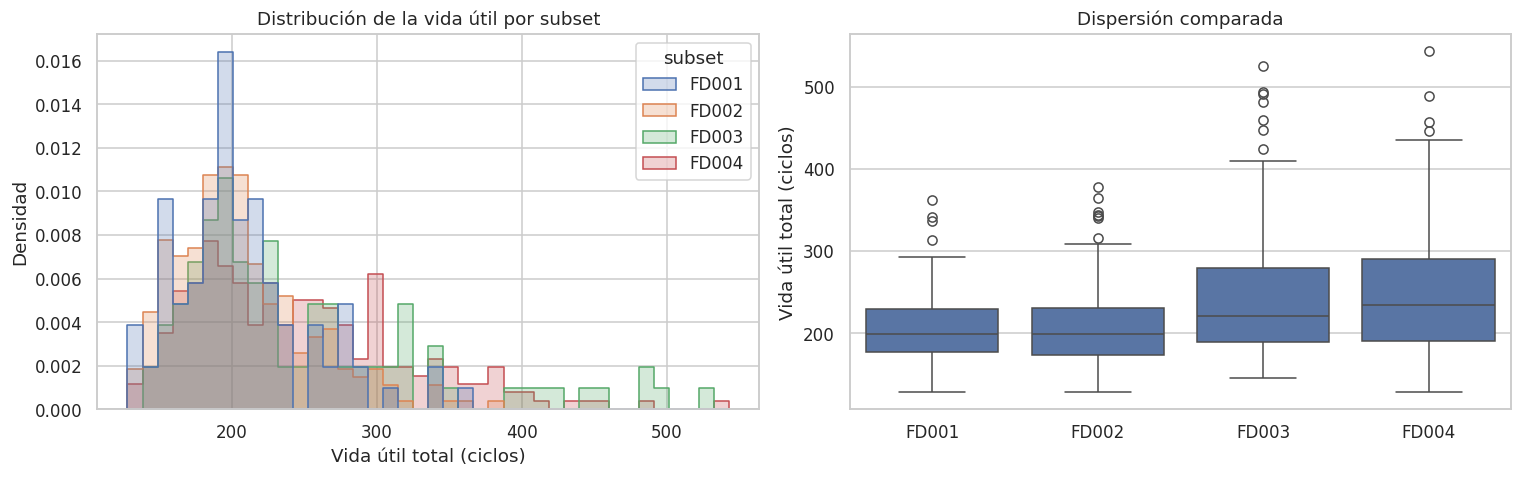

,count,mean,std,min,25%,50%,75%,max
subset,,,,,,,,
FD001,100.0,206.3,46.3,128.0,177.0,199.0,229.2,362.0
FD002,260.0,206.8,46.8,128.0,174.0,199.0,230.2,378.0
FD003,100.0,247.2,86.5,145.0,189.8,220.5,279.8,525.0
FD004,249.0,246.0,73.1,128.0,190.0,234.0,290.0,543.0


In [ ]:
vidas = []
for name, s in subsets.items():
    v = s.train.groupby("unit")["cycle"].max()
    vidas.append(pd.DataFrame({"subset": name, "vida_util": v.values}))
vidas = pd.concat(vidas, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(data=vidas, x="vida_util", hue="subset", element="step",
             stat="density", common_norm=False, bins=40, ax=axes[0])
axes[0].set_xlabel("Vida útil total (ciclos)")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Distribución de la vida útil por subset")

sns.boxplot(data=vidas, x="subset", y="vida_util", ax=axes[1])
axes[1].set_xlabel(""); axes[1].set_ylabel("Vida útil total (ciclos)")
axes[1].set_title("Dispersión comparada")

fig.tight_layout()
fig.savefig(FIG_DIR / "eda_distribucion_vida_util.png", bbox_inches="tight")
plt.show()

vidas.groupby("subset")["vida_util"].describe().round(1)

## 6. Sensores sin varianza informativa

Un sensor cuya desviación típica es nula no aporta información: es una columna constante. Para
la red equivale a un peso multiplicado por una constante, es decir, un término de sesgo
redundante.

Necesitamos primero las funciones de identificación de regímenes, porque el criterio de
descarte debe evaluarse dentro de cada uno.

In [ ]:
def fit_regime_clusterer(train, n_conditions):
    """
    Ajusta un K-Means sobre las tres variables de ajuste operativo.

    En FD002 y FD004 las combinaciones (altitud, Mach, TRA) forman seis grupos
    perfectamente separados que corresponden a seis regimenes de vuelo. En
    FD001 y FD003 solo existe un regimen y el clustering no aporta nada.
    """
    if n_conditions <= 1:
        return None
    km = KMeans(n_clusters=n_conditions, random_state=RANDOM_STATE, n_init=10)
    km.fit(train[SETTING_COLS].values)
    return km


def assign_regime(df, clusterer):
    """Indice de regimen de cada fila (0 si solo hay un regimen)."""
    if clusterer is None:
        return np.zeros(len(df), dtype=int)
    return clusterer.predict(df[SETTING_COLS].values)


def fit_regime_scalers(train, regimes, feature_cols):
    """
    Ajusta un MinMaxScaler independiente para cada regimen operativo.

    Este es el paso clave del preprocesado en FD002/FD004: la varianza que
    introduce el regimen de vuelo es muy superior a la que introduce la
    degradacion, de modo que una normalizacion global enmascararia la senal
    util.
    """
    scalers = {}
    for r in np.unique(regimes):
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaler.fit(train.loc[regimes == r, feature_cols].values)
        scalers[int(r)] = scaler
    return scalers


def apply_regime_scalers(df, regimes, scalers, feature_cols):
    """Aplica a cada fila el escalador correspondiente a su regimen."""
    df = df.copy()
    values = df[feature_cols].values.astype(np.float64)
    out = np.empty_like(values)
    for r, scaler in scalers.items():
        mask = regimes == r
        if mask.any():
            out[mask] = scaler.transform(values[mask])
    df[feature_cols] = out
    return df

In [ ]:
def find_uninformative_sensors(train, regimes=None, threshold=1e-6):
    """
    Identifica sensores sin varianza informativa.

    En FD001 esto descarta 7 de los 21 sensores. Se detecta de forma empirica
    en lugar de codificar una lista fija, de modo que el criterio se adapta a
    cada subset.

    IMPORTANTE: el calculo debe hacerse DENTRO de cada regimen operativo. En
    FD002 y FD004 varios sensores son constantes dentro de cada regimen de
    vuelo pero toman un valor distinto en cada uno. Medida globalmente su
    desviacion tipica es alta y pareceria que aportan informacion, cuando en
    realidad solo estan codificando el regimen, no el estado de degradacion.

    Criterio aplicado: se descarta un sensor si su desviacion tipica es
    despreciable en TODOS los regimenes (se toma el maximo entre regimenes).
    """
    if regimes is None:
        stds = train[SENSOR_COLS].std()
    else:
        per_regime = [train.loc[regimes == r, SENSOR_COLS].std()
                      for r in np.unique(regimes)]
        stds = pd.concat(per_regime, axis=1).max(axis=1)

    return sorted(stds[stds < threshold].index.tolist(),
                  key=lambda c: int(c.split("_")[1]))

In [ ]:
descartes = {}
for name, s in subsets.items():
    clusterer = fit_regime_clusterer(s.train, s.n_conditions)
    regimes   = assign_regime(s.train, clusterer)
    globales  = find_uninformative_sensors(s.train, regimes=None)
    por_reg   = find_uninformative_sensors(s.train, regimes=regimes)
    descartes[name] = {
        "criterio_global": len(globales),
        "criterio_por_regimen": len(por_reg),
        "sensores_descartados": ", ".join(c.replace("sensor_", "S") for c in por_reg),
    }

pd.DataFrame(descartes).T

,criterio_global,criterio_por_regimen,sensores_descartados
FD001,6,6,"S1, S5, S10, S16, S18, S19"
FD002,0,4,"S1, S5, S18, S19"
FD003,5,5,"S1, S5, S16, S18, S19"
FD004,0,4,"S1, S5, S18, S19"


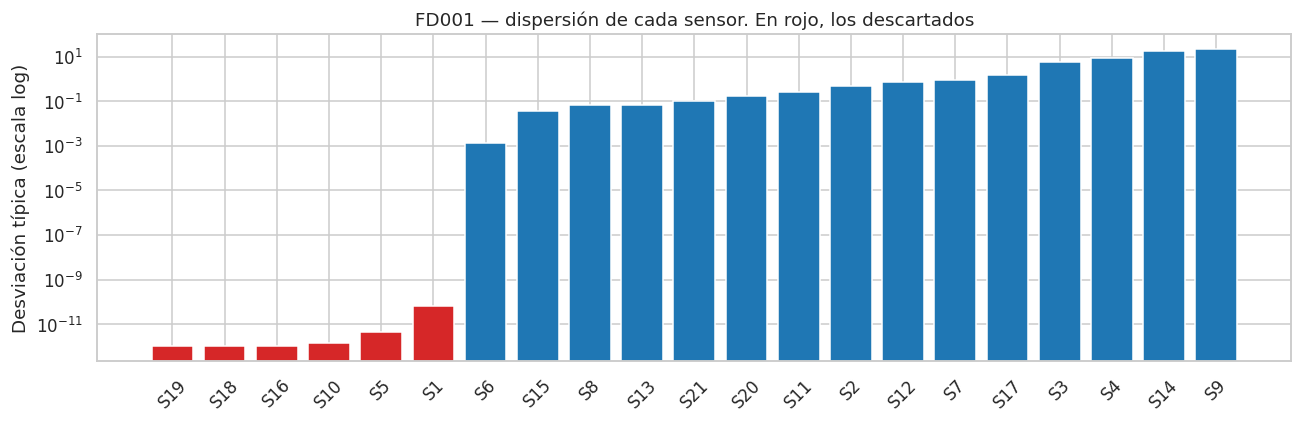

In [ ]:
# Desviación típica de cada sensor en FD001, en escala logarítmica
stds = subsets["FD001"].train[SENSOR_COLS].std().sort_values()

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["tab:red" if v < 1e-6 else "tab:blue" for v in stds.values]
ax.bar(range(len(stds)), stds.values + 1e-12, color=colors)
ax.set_yscale("log")
ax.set_xticks(range(len(stds)))
ax.set_xticklabels([c.replace("sensor_", "S") for c in stds.index], rotation=45)
ax.set_ylabel("Desviación típica (escala log)")
ax.set_title("FD001 — dispersión de cada sensor. En rojo, los descartados")
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_varianza_sensores.png", bbox_inches="tight")
plt.show()

Los 6 sensores descartados en FD001 se agrupan en tres familias con explicación física:

| Sensor | Magnitud | Motivo |
|---|---|---|
| S1 (T2), S5 (P2) | Temperatura y presión a la entrada | Condiciones ambiente, fijas a nivel del mar |
| S10 (epr), S16 (farB) | Ratios regulados | El lazo de control los mantiene en consigna |
| S18 (Nf_dmd), S19 (PCNfR_dmd) | Velocidades *demandadas* | Son consignas del controlador, no medidas del motor |

Los dos últimos son especialmente ilustrativos: Nf_dmd no mide lo que el motor hace, sino
lo que el controlador le pide. Un motor degradado y uno nuevo reciben la misma orden; lo que
cambia es cuánto esfuerzo les cuesta cumplirla, y eso aparece en otros sensores.

## 7. Curvas de degradación

Evolución de varios sensores a lo largo de la vida de unos pocos motores de FD001, con el eje
temporal invertido para que el fallo quede en el origen y las trayectorias sean comparables
entre motores de distinta duración.

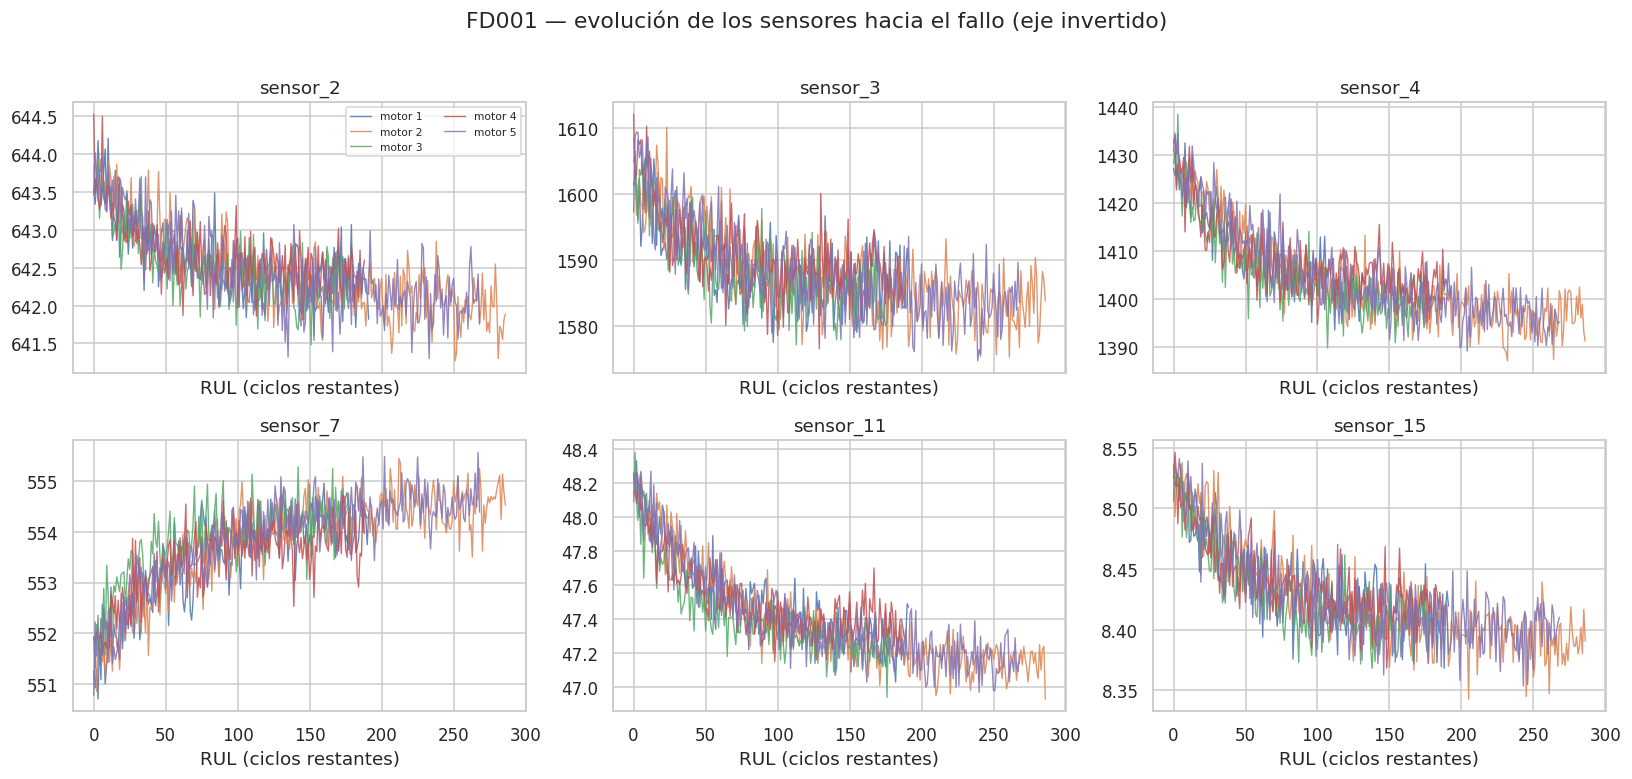

In [ ]:
sensores_interes = ["sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_11", "sensor_15"]
motores = [1, 2, 3, 4, 5]

df = subsets["FD001"].train
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)

for ax, sensor in zip(axes.ravel(), sensores_interes):
    for u in motores:
        g = df[df["unit"] == u].sort_values("cycle")
        rul = g["cycle"].max() - g["cycle"]
        ax.plot(rul, g[sensor], lw=0.9, alpha=0.85, label=f"motor {u}")
    ax.invert_xaxis()
    ax.set_title(sensor)
    ax.set_xlabel("RUL (ciclos restantes)")
axes[0, 0].legend(fontsize=7, ncol=2)

fig.suptitle("FD001 — evolución de los sensores hacia el fallo (eje invertido)", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_curvas_degradacion.png", bbox_inches="tight")
plt.show()

## 8. Regímenes operativos

Las tres variables de ajuste operativo son la altitud, el número de Mach y el ángulo de la
palanca de gases (TRA). En FD002 y FD004 no toman valores continuos arbitrarios: se agrupan en
seis combinaciones discretas que corresponden a seis regímenes de vuelo.

Conviene subrayar que no se refieren a marchas y paros. Cada ciclo es un vuelo completo en
los cuatro subsets; lo que distingue a FD002 es que sus vuelos se realizan en condiciones muy
distintas entre sí.

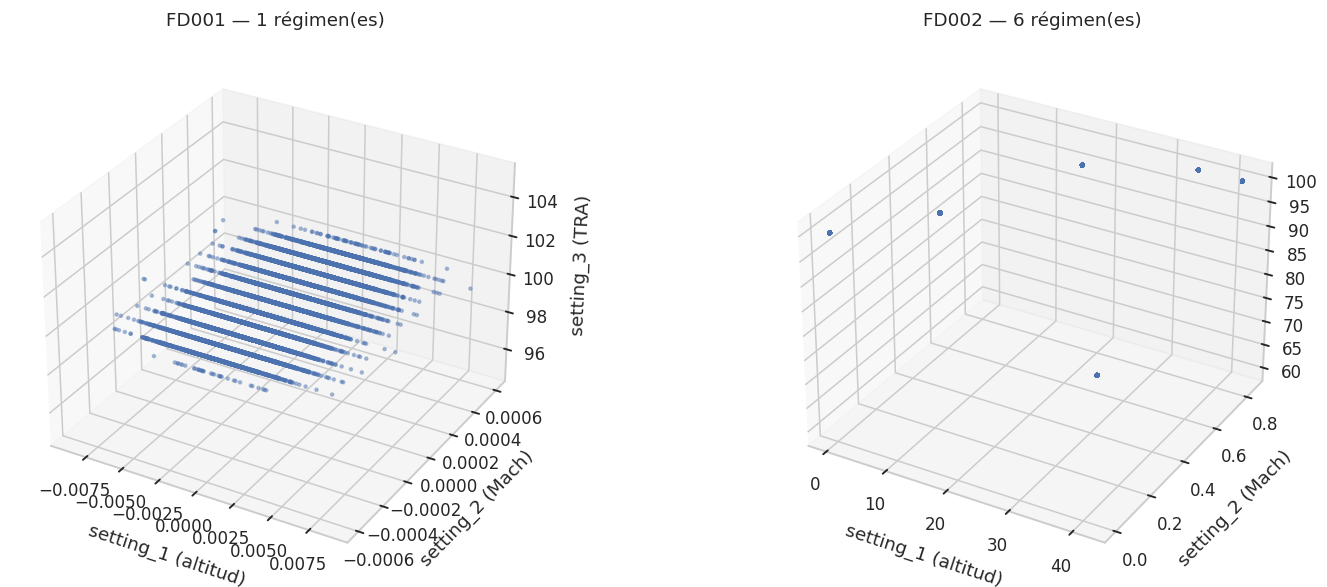

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), subplot_kw={"projection": "3d"})

for ax, name in zip(axes, ["FD001", "FD002"]):
    s = subsets[name]
    m = s.train[SETTING_COLS].values
    ax.scatter(m[:, 0], m[:, 1], m[:, 2], s=4, alpha=0.4)
    ax.set_xlabel("setting_1 (altitud)", labelpad=8)
    ax.set_ylabel("setting_2 (Mach)", labelpad=8)
    ax.set_zlabel("setting_3 (TRA)", labelpad=8)
    ax.set_title(f"{name} — {s.n_conditions} régimen(es)", pad=15)

fig.tight_layout()
fig.savefig(FIG_DIR / "eda_regimenes_3d.png", bbox_inches="tight")
plt.show()

In [ ]:
# Caracterización numérica de los seis regímenes de FD002
s = subsets["FD002"]
clusterer_fd002 = fit_regime_clusterer(s.train, s.n_conditions)
regimes_fd002 = assign_regime(s.train, clusterer_fd002)

tabla_regimenes = (
    s.train[SETTING_COLS]
    .assign(regimen=regimes_fd002)
    .groupby("regimen")
    .agg(["mean", "count"])
    .round(3)
)
tabla_regimenes

setting_1        setting_2        setting_3       
             mean  count      mean  count      mean  count
regimen                                                   
0           0.002   8044     0.000   8044     100.0   8044
1          35.003   8037     0.841   8037     100.0   8037
2          25.003   8002     0.621   8002      60.0   8002
3          10.003   8096     0.250   8096     100.0   8096
4          20.003   8122     0.701   8122     100.0   8122
5          42.003  13458     0.840  13458     100.0  13458

## 9. Efecto de la normalización por régimen

Esta es la figura que justifica visualmente la decisión de preprocesado más importante del
proyecto. Se compara la misma señal de un mismo motor antes y después de normalizar dentro de
su régimen.

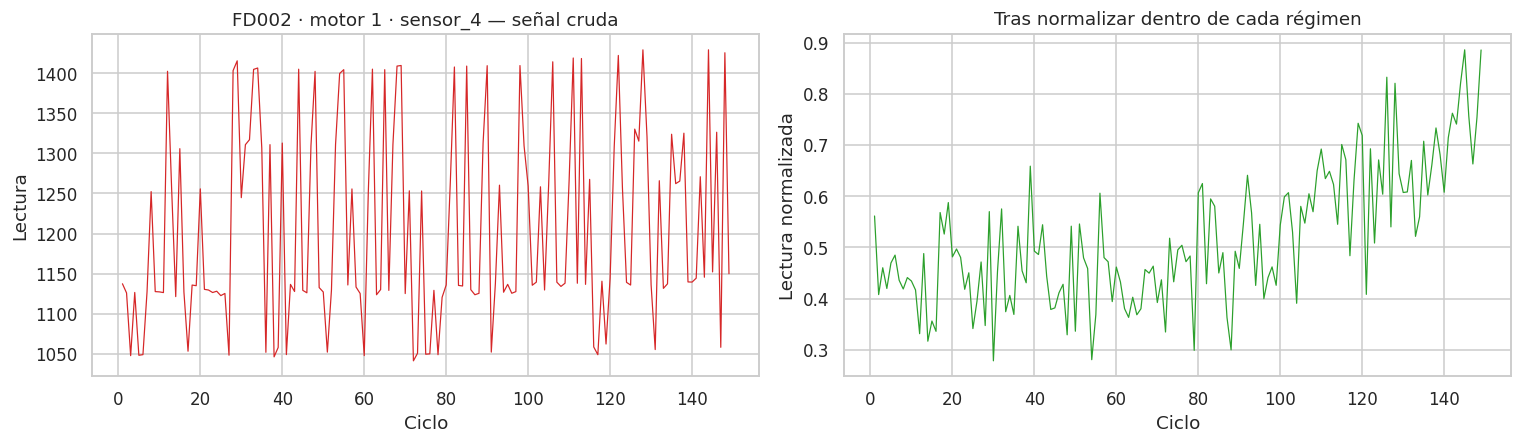

In [ ]:
SENSOR = "sensor_4"
MOTOR  = 1

train_fd002 = s.train.copy()
scalers = fit_regime_scalers(train_fd002, regimes_fd002, list(SENSOR_COLS))
train_norm = apply_regime_scalers(train_fd002, regimes_fd002, scalers, list(SENSOR_COLS))

g_raw  = train_fd002[train_fd002["unit"] == MOTOR].sort_values("cycle")
g_norm = train_norm[train_norm["unit"] == MOTOR].sort_values("cycle")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharex=True)

axes[0].plot(g_raw["cycle"], g_raw[SENSOR], lw=0.8, color="tab:red")
axes[0].set_title(f"FD002 · motor {MOTOR} · {SENSOR} — señal cruda")
axes[0].set_xlabel("Ciclo"); axes[0].set_ylabel("Lectura")

axes[1].plot(g_norm["cycle"], g_norm[SENSOR], lw=0.8, color="tab:green")
axes[1].set_title("Tras normalizar dentro de cada régimen")
axes[1].set_xlabel("Ciclo"); axes[1].set_ylabel("Lectura normalizada")

fig.tight_layout()
fig.savefig(FIG_DIR / "eda_normalizacion_por_regimen.png", bbox_inches="tight")
plt.show()

## 10. Correlación de los sensores con el RUL

In [ ]:
def add_rul_train(df, rul_cap=125):
    """
    Anade la columna RUL al conjunto de entrenamiento.

    En train cada motor se opera hasta el fallo, luego para un ciclo dado:
        RUL = ultimo_ciclo_del_motor - ciclo_actual

    Si `rul_cap` no es None se aplica RUL = min(RUL, rul_cap), obteniendo el
    perfil de degradacion lineal a trozos. La justificacion es que un motor
    nuevo no se degrada de forma apreciable: exigir al modelo que distinga
    entre 300 y 290 ciclos restantes no tiene reflejo fisico en los sensores.
    """
    df = df.copy()
    max_cycle = df.groupby("unit")["cycle"].transform("max")
    df["RUL"] = max_cycle - df["cycle"]
    if rul_cap is not None:
        df["RUL"] = df["RUL"].clip(upper=rul_cap)
    return df


def add_rul_test(df, rul_test, rul_cap=125):
    """
    Anade la columna RUL al conjunto de test.

    En test las series estan truncadas antes del fallo. El fichero
    RUL_FD00X.txt indica cuantos ciclos le quedaban a cada motor tras su
    ultima observacion, de modo que:
        RUL(ciclo) = (ultimo_ciclo_observado - ciclo) + RUL_restante
    """
    df = df.copy()
    max_cycle = df.groupby("unit")["cycle"].transform("max")
    remaining = df["unit"].map(rul_test)
    df["RUL"] = (max_cycle - df["cycle"]) + remaining
    if rul_cap is not None:
        df["RUL"] = df["RUL"].clip(upper=rul_cap)
    return df

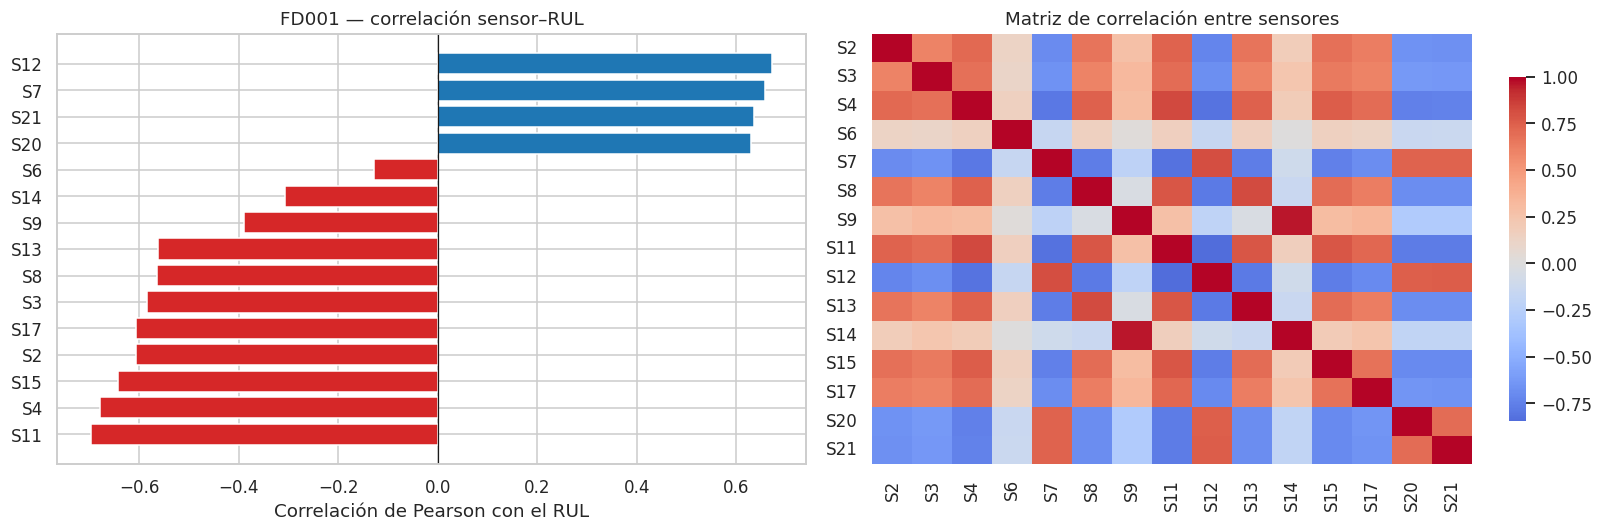

In [ ]:
df001 = add_rul_train(subsets["FD001"].train, rul_cap=None)
utiles = [c for c in SENSOR_COLS
          if c not in find_uninformative_sensors(subsets["FD001"].train)]

corr = df001[utiles + ["RUL"]].corr()["RUL"].drop("RUL").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ["tab:red" if v < 0 else "tab:blue" for v in corr.values]
axes[0].barh([c.replace("sensor_", "S") for c in corr.index], corr.values, color=colors)
axes[0].set_xlabel("Correlación de Pearson con el RUL")
axes[0].set_title("FD001 — correlación sensor–RUL")
axes[0].axvline(0, color="k", lw=0.8)

sns.heatmap(df001[utiles].corr(), cmap="coolwarm", center=0, ax=axes[1],
            xticklabels=[c.replace("sensor_", "S") for c in utiles],
            yticklabels=[c.replace("sensor_", "S") for c in utiles],
            cbar_kws={"shrink": 0.8})
axes[1].set_title("Matriz de correlación entre sensores")

fig.tight_layout()
fig.savefig(FIG_DIR / "eda_correlaciones.png", bbox_inches="tight")
plt.show()